In [245]:
# Import required libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from scipy import stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

# Set publication-quality style
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

print("Libraries imported successfully")

Libraries imported successfully


# Figure 6: GPP and SIF Spatial and Temporal Comparison (Updated)

**Addressing reviewer comments:**
- Added PFT-aggregated density insets to spatial panels (a and b)
- Kept temporal panels (c and d) - to be merged with Figure 7 later
- Increased label sizes for publication quality
- 2×2 layout: Spatial maps (top row) + Temporal comparisons (bottom row)

## 1. Define Paths and Parameters

In [246]:
# Base directory
base_dir = Path('/home/renatob/data/FluoData1/aviris_dangermond')
output_dir = base_dir / 'shift_dangermond_trait' / 'figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Dates for analysis (13 AVIRIS flights)
dates = [
    "2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
    "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
    "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
    "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
    "2022-05-29T00:00:00.000000"
]

# File paths
base_file_path_trait = base_dir / 'fitting' / 'fitted_prescribed_lai_ci' / 'shift_fluxes_day_{:02d}_clima_fit_reg_jmax.nc'
base_file_path_pft = base_dir / 'fitting' / 'fitted_prescribed_lai_ci' / 'pft_shift_fluxes_day_{:02d}_clima_fit_reg_jmax.nc'
pft_file = base_dir / 'California_Vegetation_WHRTYPE_Dangermond' / 'output_latlon.nc'

print(f"Processing {len(dates)} dates")
print(f"Output directory: {output_dir}")

Processing 13 dates
Output directory: /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures


## 2. Load PFT Map

In [247]:
# Load PFT map
print("Loading PFT map...")
pft_ds = xr.open_dataset(pft_file)
pft_map = pft_ds['Band1'].values

print(f"PFT map shape: {pft_map.shape}")
print(f"Unique PFT values: {np.unique(pft_map[~np.isnan(pft_map)])}")

# Get coordinates from first flux file
first_file = str(base_file_path_trait).format(0)
with xr.open_dataset(first_file, decode_times=False) as ds:
    lats = ds['lat'].values
    lons = ds['lon'].values
    
print(f"Coordinate ranges: Lat [{lats.min():.4f}, {lats.max():.4f}], Lon [{lons.min():.4f}, {lons.max():.4f}]")

Loading PFT map...
PFT map shape: (458, 492)
Unique PFT values: [1. 2. 3. 4. 5. 6. 7.]
Coordinate ranges: Lat [34.4413, 34.5776], Lon [-120.5019, -120.3555]


## 3. Process Flux Files and Calculate Spatial Differences + Temporal Means

In [248]:
# Initialize lists to collect spatial differences for each date
gpp_diff_list = []
sif_diff_list = []
gpp_trait_temporal = []
gpp_pft_temporal = []
sif_trait_temporal = []
sif_pft_temporal = []

print("Processing flux files...")
# Process each date
for i, date in enumerate(dates):
    file_trait = str(base_file_path_trait).format(i)
    file_pft = str(base_file_path_pft).format(i)
    
    # Open datasets with decode_times=False to avoid datetime issues
    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)
    
    # Extract GPP and SIF
    gpp_trait = ds_trait['gpp'].values
    gpp_pft = ds_pft['gpp'].values
    sif_trait = ds_trait['sif740'].values
    sif_pft = ds_pft['sif740'].values
    
    # Calculate spatial differences and store in lists
    gpp_diff_list.append(gpp_trait - gpp_pft)
    sif_diff_list.append(sif_trait - sif_pft)
    
    # Calculate temporal means (spatial average for each date)
    gpp_trait_temporal.append(np.nanmean(gpp_trait))
    gpp_pft_temporal.append(np.nanmean(gpp_pft))
    sif_trait_temporal.append(np.nanmean(sif_trait))
    sif_pft_temporal.append(np.nanmean(sif_pft))
    
    ds_trait.close()
    ds_pft.close()
    
    if (i + 1) % 5 == 0:
        print(f"  Processed {i + 1}/{len(dates)} dates")

# Calculate temporal averages for spatial maps using nanmean across dates
# This properly handles NaN values - pixels with some valid dates will show data
gpp_diff_spatial = np.nanmean(gpp_diff_list, axis=0)
sif_diff_spatial = np.nanmean(sif_diff_list, axis=0)

# Squeeze out singleton time dimension
print(f"\nOriginal shapes: gpp={gpp_diff_spatial.shape}, sif={sif_diff_spatial.shape}")
gpp_diff_spatial = gpp_diff_spatial.squeeze()
sif_diff_spatial = sif_diff_spatial.squeeze()
print(f"After squeeze: gpp={gpp_diff_spatial.shape}, sif={sif_diff_spatial.shape}")

# Convert dates to datetime objects for temporal plots
date_objects = pd.to_datetime(dates)

print(f"\nSpatial mean GPP difference: {np.nanmean(gpp_diff_spatial):.3f} ± {np.nanstd(gpp_diff_spatial):.3f} µmol/m²/s")
print(f"Spatial mean SIF difference: {np.nanmean(sif_diff_spatial):.4f} ± {np.nanstd(sif_diff_spatial):.4f} mW/m²/nm/sr")
print(f"\nTemporal means collected for {len(date_objects)} dates")

Processing flux files...
  Processed 5/13 dates
  Processed 10/13 dates

Original shapes: gpp=(1, 458, 492), sif=(1, 458, 492)
After squeeze: gpp=(458, 492), sif=(458, 492)

Spatial mean GPP difference: 0.303 ± 2.678 µmol/m²/s
Spatial mean SIF difference: 0.0061 ± 0.0301 mW/m²/nm/sr

Temporal means collected for 13 dates


/tmp/ipykernel_4157631/112614547.py:43: RuntimeWarning: Mean of empty slice
  gpp_diff_spatial = np.nanmean(gpp_diff_list, axis=0)
/tmp/ipykernel_4157631/112614547.py:44: RuntimeWarning: Mean of empty slice
  sif_diff_spatial = np.nanmean(sif_diff_list, axis=0)


## 4. Define Plotting Functions

In [249]:
def add_density_inset_pft(ax, data, pft_map, variable_name, position='lower right'):
    """
    Add density distribution inset aggregated per PFT.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to add the inset to
    data : numpy array
        2D spatial data array
    pft_map : numpy array
        2D PFT classification map
    variable_name : str
        Name of the variable for labeling
    position : str
        Position of inset ('lower right', 'upper right', etc.)
    """
    # Create inset axes (28% size, positioned lower)
    if position == 'lower right':
        axins = inset_axes(ax, width="28%", height="28%", loc='lower right',
                          bbox_to_anchor=(0.05, 0.1, 0.9, 0.9), bbox_transform=ax.transAxes,
                          borderpad=0)
    else:
        axins = inset_axes(ax, width="28%", height="28%", loc=position, borderpad=1.0)
    
    # Define PFT colors (green, blue, red) - data values 2,3,4 labeled as 1,2,3
    pft_colors = {2: 'green', 3: 'blue', 4: 'red'}
    pft_names = {2: 'PFT 1', 3: 'PFT 2', 4: 'PFT 3'}
    
    # Flatten data and remove NaNs
    flat_data = data.flatten()
    flat_pft = pft_map.flatten()
    
    valid_mask = ~np.isnan(flat_data) & ~np.isnan(flat_pft)
    flat_data = flat_data[valid_mask]
    flat_pft = flat_pft[valid_mask]
    
    # Calculate overall statistics
    data_mean = np.mean(flat_data)
    data_std = np.std(flat_data)
    
    # Plot density for each PFT (data values 2, 3, 4)
    for pft_id in [2, 3, 4]:
        pft_data = flat_data[flat_pft == pft_id]
        if len(pft_data) > 0:
            axins.hist(pft_data, bins=40, alpha=0.6, density=True, 
                      color=pft_colors[pft_id], label=pft_names[pft_id],
                      edgecolor='black', linewidth=0.5)
    
    # Add reference lines
    axins.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Zero')
    axins.axvline(data_mean, color='black', linestyle='--', linewidth=1.5, alpha=0.8, label='Mean')
    
    # Styling
    axins.set_xlabel(f'Δ{variable_name}', fontsize=10, fontweight='bold')
    if variable_name == 'GPP':
        axins.set_xlim(-10, 10)
    elif variable_name == 'SIF':
        axins.set_xlim(-0.1, 0.1)
    axins.set_ylabel('Density', fontsize=10)
    axins.tick_params(labelsize=8)
    axins.legend(fontsize=5, loc='upper right', framealpha=0.9)
    axins.grid(True, alpha=0.3, linewidth=0.5)
    axins.set_facecolor('white')
    axins.patch.set_alpha(0.95)
    
    # Add border
    for spine in axins.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    return axins

print("Plotting functions defined")

Plotting functions defined


## 5. Create Figure 6 - Complete 2×2 Layout (Panels a, b, c, d)

**Layout:**
- **Top row**: Spatial difference maps (a=GPP, b=SIF) with PFT-aggregated density insets
- **Bottom row**: Temporal comparisons (c=GPP, d=SIF) showing Trait vs PFT over time

In [250]:
# Create figure with 2x2 layout (spatial + temporal)
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)

# Create meshgrid for plotting
LON, LAT = np.meshgrid(lons, lats)

# ========== Panel a: GPP spatial difference map ==========
ax1 = axes[0, 0]
im1 = ax1.pcolormesh(LON, LAT, gpp_diff_spatial, cmap='RdBu_r',
                     vmin=-5, vmax=5, shading='auto', rasterized=True)
ax1.set_aspect('equal')

# Panel label (outside plot, top left, aligned)
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')

# Add statistics box
gpp_mean = np.nanmean(gpp_diff_spatial)
gpp_std = np.nanstd(gpp_diff_spatial)
stats_text = f'Mean: {gpp_mean:.2f}\nSTD: {gpp_std:.2f}'
ax1.text(0.98, 0.98, stats_text, transform=ax1.transAxes, fontsize=14,
         va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Colorbar
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02, fraction=0.046)
cbar1.set_label(r'GPP Difference (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
cbar1.ax.tick_params(labelsize=13)

# Add density inset aggregated per PFT
add_density_inset_pft(ax1, gpp_diff_spatial, pft_map, 'GPP', position='lower right')

# Axis labels with reduced ticks
ax1.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.locator_params(axis='x', nbins=3)
ax1.locator_params(axis='y', nbins=3)

# ========== Panel b: SIF spatial difference map ==========
ax2 = axes[0, 1]
im2 = ax2.pcolormesh(LON, LAT, sif_diff_spatial, cmap='RdBu_r',
                     vmin=-0.1, vmax=0.1, shading='auto', rasterized=True)
ax2.set_aspect('equal')

# Panel label (outside plot, top left, aligned with b)
ax2.text(-0.15, 1.05, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')

# Add statistics box
sif_mean = np.nanmean(sif_diff_spatial)
sif_std = np.nanstd(sif_diff_spatial)
stats_text = f'Mean: {sif_mean:.2f}\nSTD: {sif_std:.2f}'
ax2.text(0.98, 0.98, stats_text, transform=ax2.transAxes, fontsize=14,
         va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))

# Colorbar
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02, fraction=0.046)
cbar2.set_label(r'SIF$_{740nm}$ Difference (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=16, fontweight='bold')
cbar2.ax.tick_params(labelsize=13)
from matplotlib.ticker import FormatStrFormatter
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# Add density inset aggregated per PFT
add_density_inset_pft(ax2, sif_diff_spatial, pft_map, 'SIF', position='lower right')

# Axis labels with reduced ticks
ax2.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax2.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.locator_params(axis='x', nbins=3)
ax2.locator_params(axis='y', nbins=3)

# ========== Panel c: GPP temporal comparison ==========
# Calculate 95% confidence interval for temporal means (per date)
from scipy.stats import sem, t

gpp_trait_temporal_std = []
gpp_trait_temporal_n = []
gpp_pft_temporal_std = []
gpp_pft_temporal_n = []
for i, date in enumerate(dates):
    file_trait = str(base_file_path_trait).format(i)
    file_pft = str(base_file_path_pft).format(i)
    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)
    gpp_trait_vals = ds_trait['gpp'].values.flatten()
    gpp_pft_vals = ds_pft['gpp'].values.flatten()
    gpp_trait_vals = gpp_trait_vals[~np.isnan(gpp_trait_vals)]
    gpp_pft_vals = gpp_pft_vals[~np.isnan(gpp_pft_vals)]
    gpp_trait_temporal_std.append(np.nanstd(gpp_trait_vals))
    gpp_trait_temporal_n.append(len(gpp_trait_vals))
    gpp_pft_temporal_std.append(np.nanstd(gpp_pft_vals))
    gpp_pft_temporal_n.append(len(gpp_pft_vals))
    ds_trait.close()
    ds_pft.close()

gpp_trait_temporal_sem = np.array(gpp_trait_temporal_std) / np.sqrt(np.array(gpp_trait_temporal_n))
gpp_pft_temporal_sem = np.array(gpp_pft_temporal_std) / np.sqrt(np.array(gpp_pft_temporal_n))
# 95% CI multiplier (two-sided)
gpp_trait_ci95 = gpp_trait_temporal_sem * t.ppf(0.975, np.array(gpp_trait_temporal_n)-1)
gpp_pft_ci95 = gpp_pft_temporal_sem * t.ppf(0.975, np.array(gpp_pft_temporal_n)-1)

ax3 = axes[1, 0]
ax3.plot(date_objects, gpp_trait_temporal, label='Trait', marker='o', color='blue', 
         linewidth=2, markersize=6)
ax3.fill_between(date_objects, 
                 np.array(gpp_trait_temporal) - gpp_trait_ci95,
                 np.array(gpp_trait_temporal) + gpp_trait_ci95,
                 color='blue', alpha=0.18, linewidth=0)
ax3.plot(date_objects, gpp_pft_temporal, label='PFT', marker='s', color='orange', 
         linewidth=2, markersize=6)
ax3.fill_between(date_objects, 
                 np.array(gpp_pft_temporal) - gpp_pft_ci95,
                 np.array(gpp_pft_temporal) + gpp_pft_ci95,
                 color='orange', alpha=0.18, linewidth=0)

# Panel label (outside plot, top left, aligned with a)
ax3.text(-0.15, 1.05, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')

# Format panel c
ax3.set_xlabel('Date', fontsize=15, fontweight='bold')
ax3.set_ylabel(r'GPP (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=15, fontweight='bold')
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.legend(loc='best', fontsize=13, framealpha=0.9)
ax3.grid(axis='y', linestyle='--', alpha=0.6)

# Format dates
import matplotlib.dates as mdates
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ========== Panel d: SIF temporal comparison ==========
# Calculate 95% confidence interval for temporal means (per date)
sif_trait_temporal_std = []
sif_trait_temporal_n = []
sif_pft_temporal_std = []
sif_pft_temporal_n = []
for i, date in enumerate(dates):
    file_trait = str(base_file_path_trait).format(i)
    file_pft = str(base_file_path_pft).format(i)
    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)
    sif_trait_vals = ds_trait['sif740'].values.flatten()
    sif_pft_vals = ds_pft['sif740'].values.flatten()
    sif_trait_vals = sif_trait_vals[~np.isnan(sif_trait_vals)]
    sif_pft_vals = sif_pft_vals[~np.isnan(sif_pft_vals)]
    sif_trait_temporal_std.append(np.nanstd(sif_trait_vals))
    sif_trait_temporal_n.append(len(sif_trait_vals))
    sif_pft_temporal_std.append(np.nanstd(sif_pft_vals))
    sif_pft_temporal_n.append(len(sif_pft_vals))
    ds_trait.close()
    ds_pft.close()

sif_trait_temporal_sem = np.array(sif_trait_temporal_std) / np.sqrt(np.array(sif_trait_temporal_n))
sif_pft_temporal_sem = np.array(sif_pft_temporal_std) / np.sqrt(np.array(sif_pft_temporal_n))
# 95% CI multiplier (two-sided)
sif_trait_ci95 = sif_trait_temporal_sem * t.ppf(0.975, np.array(sif_trait_temporal_n)-1)
sif_pft_ci95 = sif_pft_temporal_sem * t.ppf(0.975, np.array(sif_pft_temporal_n)-1)

ax4 = axes[1, 1]
ax4.plot(date_objects, sif_trait_temporal, label='Trait', marker='o', color='blue', 
         linewidth=2, markersize=6)
ax4.fill_between(date_objects, 
                 np.array(sif_trait_temporal) - sif_trait_ci95,
                 np.array(sif_trait_temporal) + sif_trait_ci95,
                 color='blue', alpha=0.18, linewidth=0)
ax4.plot(date_objects, sif_pft_temporal, label='PFT', marker='s', color='orange', 
         linewidth=2, markersize=6)
ax4.fill_between(date_objects, 
                 np.array(sif_pft_temporal) - sif_pft_ci95,
                 np.array(sif_pft_temporal) + sif_pft_ci95,
                 color='orange', alpha=0.18, linewidth=0)

# Panel label (outside plot, top left, aligned with b)
ax4.text(-0.15, 1.05, '(d)', transform=ax4.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')

# Format panel d
ax4.set_xlabel('Date', fontsize=15, fontweight='bold')
ax4.set_ylabel(r'SIF$_{740nm}$ (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=15, fontweight='bold')
ax4.tick_params(axis='both', which='major', labelsize=12)
ax4.legend(loc='best', fontsize=13, framealpha=0.9)
ax4.grid(axis='y', linestyle='--', alpha=0.6)

# Format dates
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Adjust layout with extra space for external labels
plt.tight_layout(rect=[0.02, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.25, wspace=0.65)


# Before saving, ensure all axes have figure references
for ax in fig.get_axes():
    if not hasattr(ax, 'figure') or ax.figure is None:
        ax.figure = fig


# Save figure
output_file = output_dir / 'figure_6_gpp_sif_spatial_temporal_revised.png'
# Force draw to initialize all renderers (fixes inset_axes issue)
fig.canvas.draw()  # ← ADD THIS LINE

#plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(output_file, dpi=300, facecolor='white')

print(f"\nFigure saved to: {output_file}")

plt.close(fig)

print("\n" + "="*80)
print("FIGURE 6 GENERATION COMPLETE")
print("="*80)
print("\n✅ Changes applied:")
print("  • Panel (a): GPP spatial difference map with PFT-aggregated density inset")
print("  • Panel (b): SIF spatial difference map with PFT-aggregated density inset")
print("  • Panel (c): GPP temporal comparison (Trait vs PFT)")
print("  • Panel (d): SIF temporal comparison (Trait vs PFT)")
print("  • Increased label sizes for publication quality")
print("  • Statistics boxes show Mean/STD for spatial panels")


/tmp/ipykernel_4157631/4039382079.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 1, 0.98])



Figure saved to: /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures/figure_6_gpp_sif_spatial_temporal_revised.png

FIGURE 6 GENERATION COMPLETE

✅ Changes applied:
  • Panel (a): GPP spatial difference map with PFT-aggregated density inset
  • Panel (b): SIF spatial difference map with PFT-aggregated density inset
  • Panel (c): GPP temporal comparison (Trait vs PFT)
  • Panel (d): SIF temporal comparison (Trait vs PFT)
  • Increased label sizes for publication quality
  • Statistics boxes show Mean/STD for spatial panels


## 6. Display Saved Figure

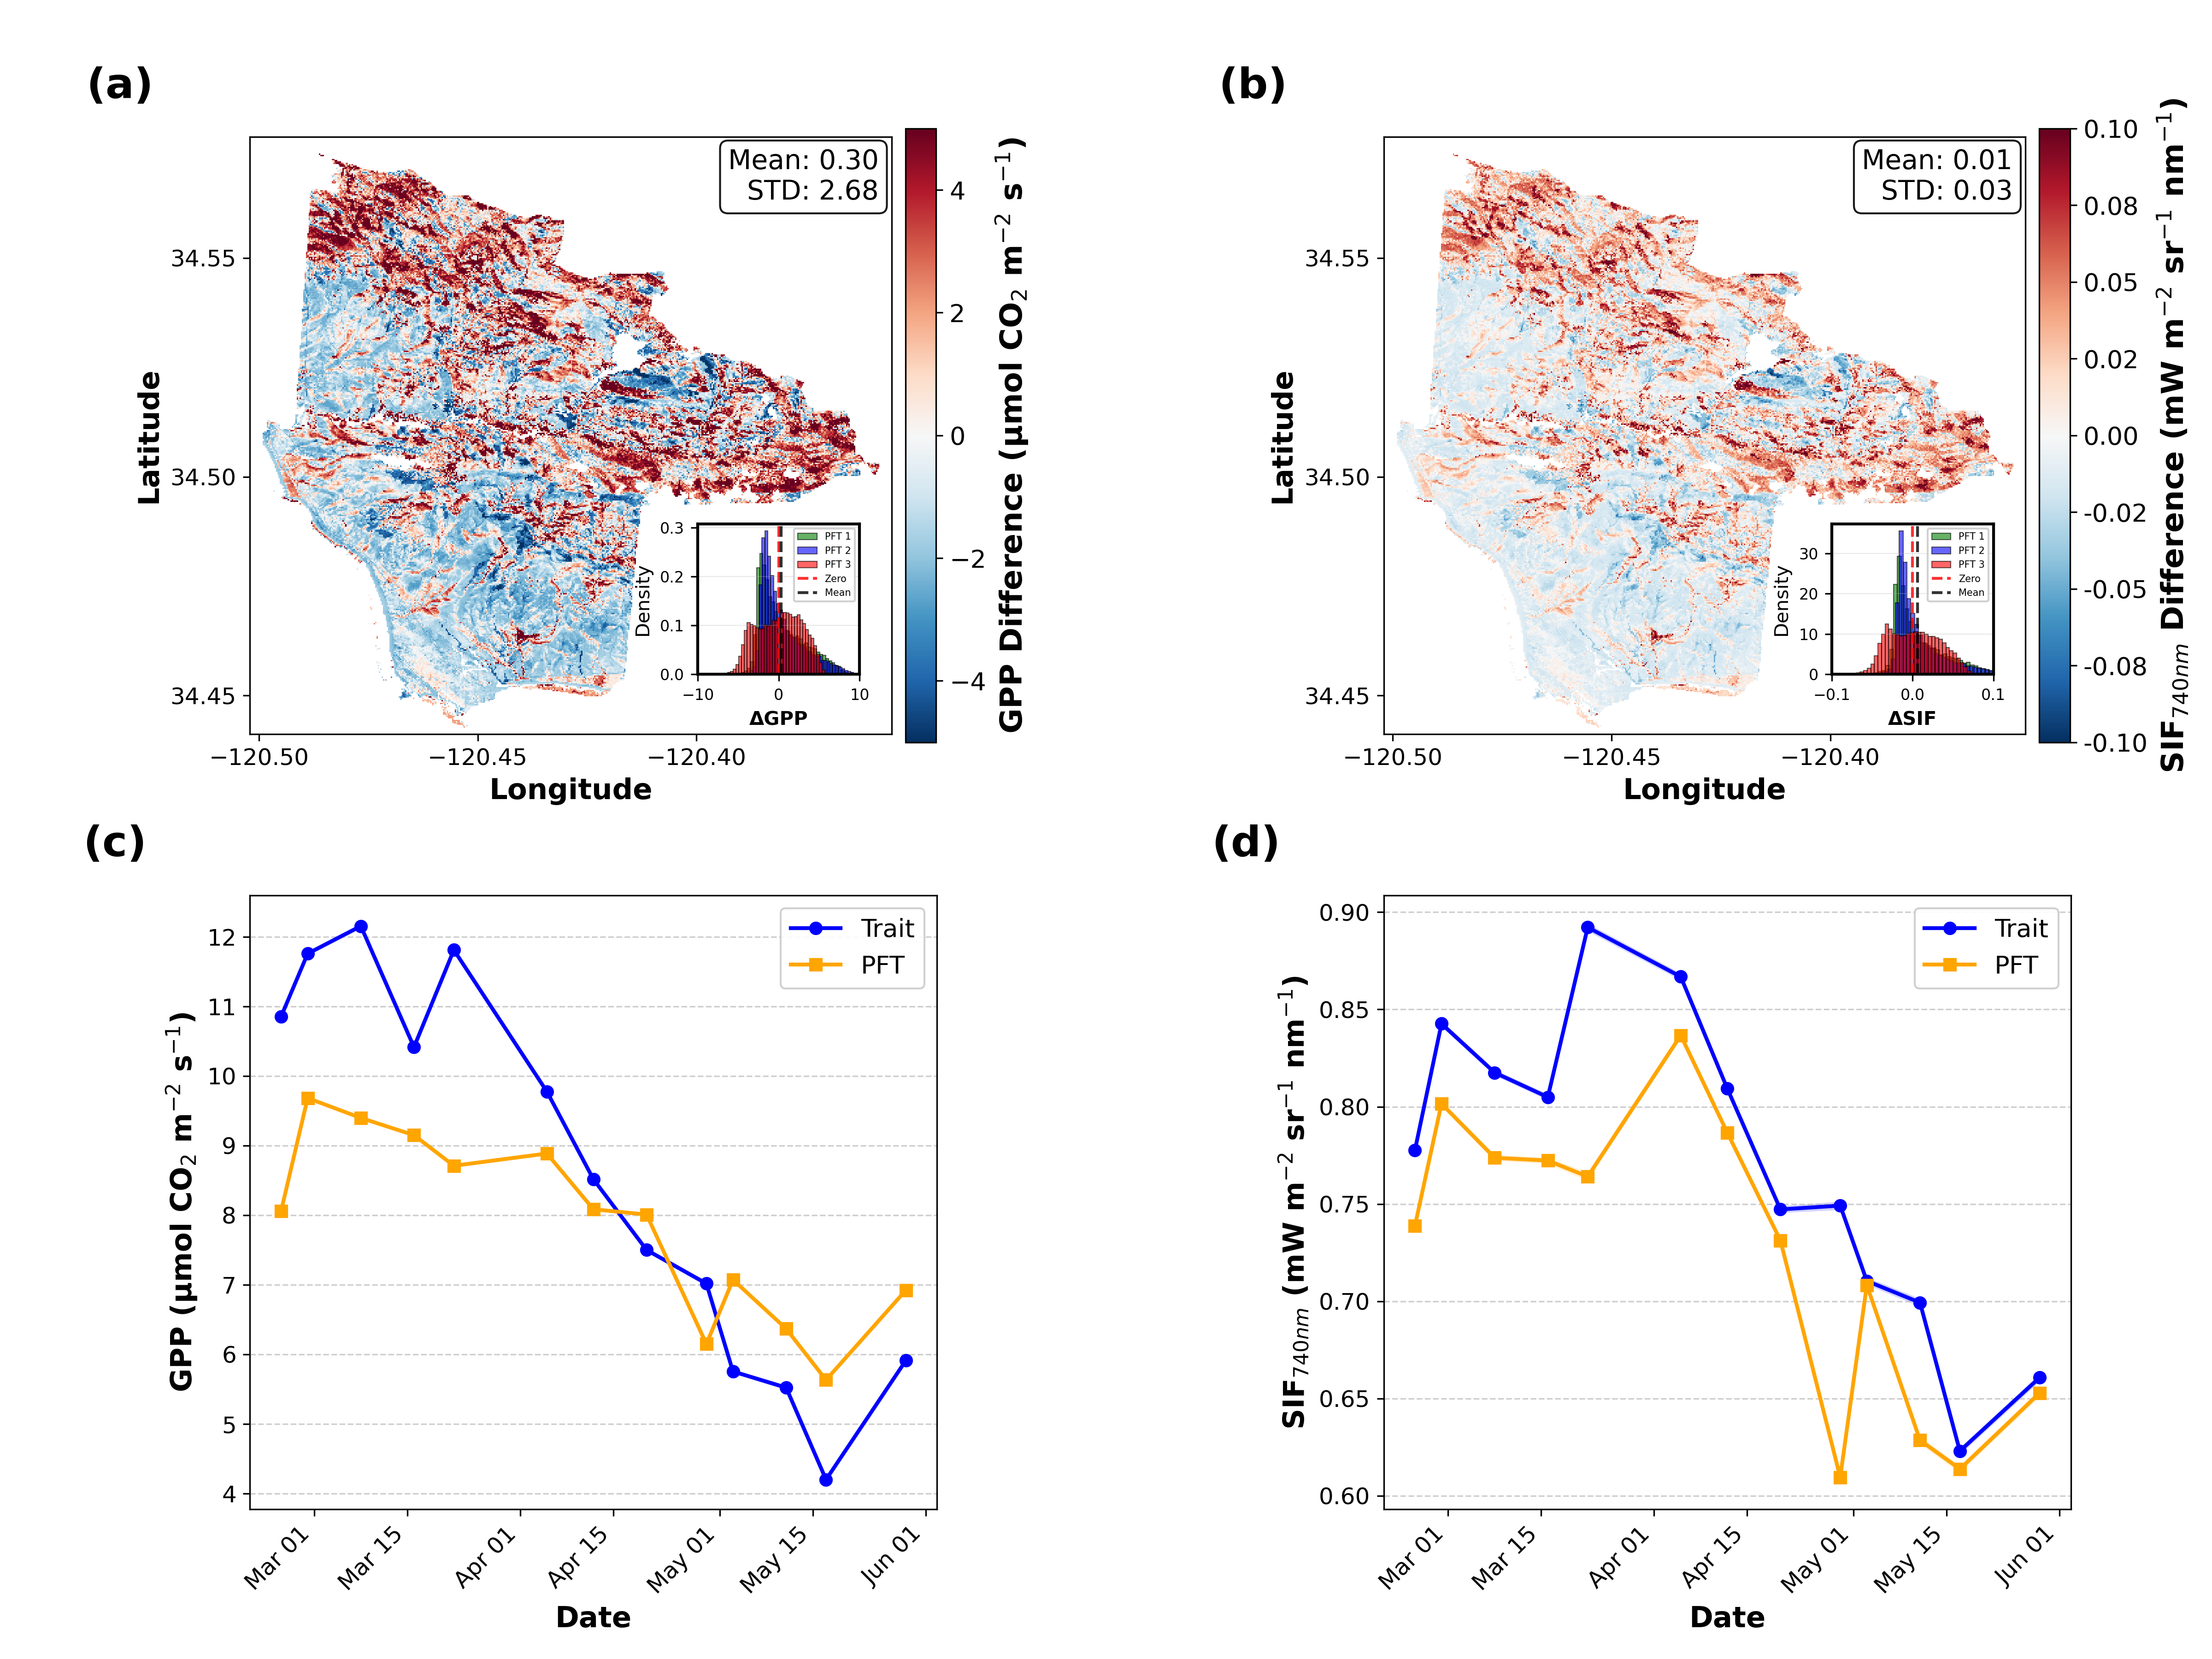

In [251]:
from IPython.display import Image, display

display(Image(filename=str(output_file), width=1400))

## 7. Summary Statistics

In [252]:
# Calculate and print detailed summary statistics
print("=" * 80)
print("FIGURE 6 SUMMARY STATISTICS")
print("=" * 80)

# Overall spatial differences
gpp_diff_flat = gpp_diff_spatial.flatten()
gpp_diff_flat = gpp_diff_flat[~np.isnan(gpp_diff_flat)]
print(f"\nGPP Spatial Difference (Trait - PFT):")
print(f"  Mean: {np.mean(gpp_diff_flat):.3f} µmol CO₂ m⁻² s⁻¹")
print(f"  Std:  {np.std(gpp_diff_flat):.3f} µmol CO₂ m⁻² s⁻¹")
print(f"  Min:  {np.min(gpp_diff_flat):.3f} µmol CO₂ m⁻² s⁻¹")
print(f"  Max:  {np.max(gpp_diff_flat):.3f} µmol CO₂ m⁻² s⁻¹")

sif_diff_flat = sif_diff_spatial.flatten()
sif_diff_flat = sif_diff_flat[~np.isnan(sif_diff_flat)]
print(f"\nSIF Spatial Difference (Trait - PFT):")
print(f"  Mean: {np.mean(sif_diff_flat):.4f} mW m⁻² sr⁻¹ nm⁻¹")
print(f"  Std:  {np.std(sif_diff_flat):.4f} mW m⁻² sr⁻¹ nm⁻¹")
print(f"  Min:  {np.min(sif_diff_flat):.4f} mW m⁻² sr⁻¹ nm⁻¹")
print(f"  Max:  {np.max(sif_diff_flat):.4f} mW m⁻² sr⁻¹ nm⁻¹")

# Per-PFT statistics
flat_pft = pft_map.flatten()
valid_mask = ~np.isnan(gpp_diff_spatial.flatten()) & ~np.isnan(flat_pft)
gpp_diff_valid = gpp_diff_spatial.flatten()[valid_mask]
sif_diff_valid = sif_diff_spatial.flatten()[valid_mask]
pft_valid = flat_pft[valid_mask]

print("\n" + "="*80)
print("PER-PFT STATISTICS")
print("="*80)

# Data values 2, 3, 4 correspond to PFTs 1, 2, 3 in paper
for data_pft_id, paper_pft_id in [(2, 1), (3, 2), (4, 3)]:
    pft_mask = pft_valid == data_pft_id
    n_pixels = pft_mask.sum()
    
    if n_pixels > 0:
        gpp_pft = gpp_diff_valid[pft_mask]
        sif_pft = sif_diff_valid[pft_mask]
        
        print(f"\nPFT {paper_pft_id} (n={n_pixels} pixels):")
        print(f"  GPP: Mean={np.mean(gpp_pft):.3f}, Std={np.std(gpp_pft):.3f}, Range=[{np.min(gpp_pft):.3f}, {np.max(gpp_pft):.3f}]")
        print(f"  SIF: Mean={np.mean(sif_pft):.4f}, Std={np.std(sif_pft):.4f}, Range=[{np.min(sif_pft):.4f}, {np.max(sif_pft):.4f}]")

print("\n" + "="*80)

FIGURE 6 SUMMARY STATISTICS

GPP Spatial Difference (Trait - PFT):
  Mean: 0.303 µmol CO₂ m⁻² s⁻¹
  Std:  2.678 µmol CO₂ m⁻² s⁻¹
  Min:  -7.666 µmol CO₂ m⁻² s⁻¹
  Max:  10.371 µmol CO₂ m⁻² s⁻¹

SIF Spatial Difference (Trait - PFT):
  Mean: 0.0061 mW m⁻² sr⁻¹ nm⁻¹
  Std:  0.0301 mW m⁻² sr⁻¹ nm⁻¹
  Min:  -0.1002 mW m⁻² sr⁻¹ nm⁻¹
  Max:  0.1373 mW m⁻² sr⁻¹ nm⁻¹

PER-PFT STATISTICS

PFT 1 (n=33142 pixels):
  GPP: Mean=0.389, Std=2.744, Range=[-5.671, 9.154]
  SIF: Mean=0.0076, Std=0.0306, Range=[-0.0710, 0.1189]

PFT 2 (n=39579 pixels):
  GPP: Mean=0.416, Std=2.584, Range=[-4.288, 10.371]
  SIF: Mean=0.0077, Std=0.0290, Range=[-0.0550, 0.1373]

PFT 3 (n=30615 pixels):
  GPP: Mean=0.063, Std=2.709, Range=[-7.666, 6.064]
  SIF: Mean=0.0023, Std=0.0308, Range=[-0.1002, 0.0767]



## 8. Export High-Resolution Version

In [253]:
# Create high-resolution version for publication
print("Creating high-resolution version (600 DPI)...")

fig_hires, axes_hires = plt.subplots(2, 2, figsize=(16, 12), dpi=600)

# Create meshgrid for plotting
LON, LAT = np.meshgrid(lons, lats)

# Panel a: GPP spatial
ax1 = axes_hires[0, 0]
im1 = ax1.pcolormesh(LON, LAT, gpp_diff_spatial, cmap='RdBu_r',
                     vmin=-5, vmax=5, shading='auto', rasterized=True)
ax1.set_aspect('equal')
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')
ax1.text(0.98, 0.98, f'Mean: {gpp_mean:.2f}\nSTD: {gpp_std:.2f}', transform=ax1.transAxes,
         fontsize=14, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02, fraction=0.046)
cbar1.set_label(r'GPP Difference (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
cbar1.ax.tick_params(labelsize=13)
add_density_inset_pft(ax1, gpp_diff_spatial, pft_map, 'GPP', position='lower right')
ax1.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.locator_params(axis='x', nbins=3)
ax1.locator_params(axis='y', nbins=3)

# Panel b: SIF spatial
ax2 = axes_hires[0, 1]
im2 = ax2.pcolormesh(LON, LAT, sif_diff_spatial, cmap='RdBu_r',
                     vmin=-0.1, vmax=0.1, shading='auto', rasterized=True)
ax2.set_aspect('equal')
ax2.text(-0.15, 1.05, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')
ax2.text(0.98, 0.98, f'Mean: {sif_mean:.2f}\nSTD: {sif_std:.2f}', transform=ax2.transAxes,
         fontsize=14, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02, fraction=0.046)
cbar2.set_label(r'SIF$_{740nm}$ Difference (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=16, fontweight='bold')
cbar2.ax.tick_params(labelsize=13)

add_density_inset_pft(ax2, sif_diff_spatial, pft_map, 'SIF', position='lower right')
from matplotlib.ticker import FormatStrFormatter
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax2.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax2.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.locator_params(axis='x', nbins=3)
ax2.locator_params(axis='y', nbins=3)

# Panel c: GPP temporal
ax3 = axes_hires[1, 0]
ax3.plot(date_objects, gpp_trait_temporal, label='Trait', marker='o', color='blue', 
         linewidth=2, markersize=6)
ax3.plot(date_objects, gpp_pft_temporal, label='PFT', marker='s', color='orange', 
         linewidth=2, markersize=6)
ax3.text(-0.15, 1.05, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')
ax3.set_xlabel('Date', fontsize=15, fontweight='bold')
ax3.set_ylabel(r'GPP (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=15, fontweight='bold')
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.legend(loc='best', fontsize=13, framealpha=0.9)
ax3.grid(axis='y', linestyle='--', alpha=0.6)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Panel d: SIF temporal
ax4 = axes_hires[1, 1]
ax4.plot(date_objects, sif_trait_temporal, label='Trait', marker='o', color='blue', 
         linewidth=2, markersize=6)
ax4.plot(date_objects, sif_pft_temporal, label='PFT', marker='s', color='orange', 
         linewidth=2, markersize=6)
ax4.text(-0.15, 1.05, '(d)', transform=ax4.transAxes, fontsize=22, fontweight='bold',
         va='bottom', ha='right')
ax4.set_xlabel('Date', fontsize=15, fontweight='bold')
ax4.set_ylabel(r'SIF$_{740nm}$ (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=15, fontweight='bold')
ax4.tick_params(axis='both', which='major', labelsize=12)
ax4.legend(loc='best', fontsize=13, framealpha=0.9)
ax4.grid(axis='y', linestyle='--', alpha=0.6)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(rect=[0.02, 0, 1, 0.98])
plt.subplots_adjust(hspace=0.2, wspace=0.3)

# Save high-resolution versions
output_hires_png = output_dir / 'figure_6_gpp_sif_spatial_temporal_600dpi.png'
output_hires_pdf = output_dir / 'figure_6_gpp_sif_spatial_temporal.pdf'

#plt.savefig(output_hires_png, dpi=600, bbox_inches='tight', facecolor='white')
#plt.savefig(output_hires_pdf, format='pdf', bbox_inches='tight', facecolor='white')

plt.savefig(output_hires_png, dpi=600,  facecolor='white')
plt.savefig(output_hires_pdf, format='pdf',  facecolor='white')

print(f"\nHigh-resolution versions saved:")
print(f"  PNG (600 DPI): {output_hires_png}")
print(f"  PDF: {output_hires_pdf}")

plt.close(fig_hires)

print("\n" + "="*80)
print("ALL VERSIONS GENERATED SUCCESSFULLY!")
print("="*80)

Creating high-resolution version (600 DPI)...


/tmp/ipykernel_4157631/127486470.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 1, 0.98])



High-resolution versions saved:
  PNG (600 DPI): /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures/figure_6_gpp_sif_spatial_temporal_600dpi.png
  PDF: /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures/figure_6_gpp_sif_spatial_temporal.pdf

ALL VERSIONS GENERATED SUCCESSFULLY!


In [254]:
# Create updated Figure 6 with panel (d) matching the Figure 7 TROPOMI workflow
print('Creating Figure 6 with Figure 7-style TROPOMI panel...')

# ---- Figure 7 logic for TROPOMI ----
from scipy.stats import linregress

def calc_ci95_area(data):
    mean = np.nanmean(data, axis=(1, 2))
    std = np.nanstd(data, axis=(1, 2))
    count = np.sum(~np.isnan(data), axis=(1, 2))
    ci95_hi = mean + 1.96 * std / np.sqrt(count)
    ci95_lo = mean - 1.96 * std / np.sqrt(count)
    return ci95_lo, ci95_hi

file_path_tropomi = base_dir / 'TROPOMI_dangermond' / 'TROPOMI_SIF740nm-v1.005deg_regrid_Dangermond_tll_clipped.nc'
ds_tropomi = xr.open_dataset(file_path_tropomi)
ds_tropomi['sif'] = ds_tropomi['sif'].where(ds_tropomi['sif'] != -999)
ds_tropomi['time'] = xr.cftime_range(start='2022-02-01', periods=len(ds_tropomi['time']), freq='D', calendar='proleptic_gregorian')
ds_tropomi['time'] = ds_tropomi.indexes['time'].to_datetimeindex()

mean_sif_tropomi = ds_tropomi['sif'].mean(dim=['lat', 'lon'], skipna=True)
weekly_mean_sif = mean_sif_tropomi.resample(time='W').mean()
weekly_std_sif = mean_sif_tropomi.resample(time='W').std()

target_dates = pd.to_datetime(dates)
average_sif_target_dates = []
for target_date in target_dates:
    start_date = target_date - pd.Timedelta(days=4)
    end_date = target_date + pd.Timedelta(days=4)
    mask = (ds_tropomi['time'] >= start_date) & (ds_tropomi['time'] <= end_date)
    average_sif_target_dates.append(mean_sif_tropomi[mask].mean().item())
average_sif_target_dates = np.array(average_sif_target_dates)

# Paths for trait and PFT NetCDFs (match Figure 7 code)
base_file_path_trait_fig7 = "/home/renatob/data/FluoData1/aviris_dangermond/fitting/fitted_prescribed_lai_ci/shift_fluxes_day_{}_clima_fit_reg_jmax.nc"
base_file_path_pft_fig7 = "/home/renatob/data/FluoData1/aviris_dangermond/fitting/fitted_prescribed_lai_ci/pft_shift_fluxes_day_{}_clima_fit_reg_jmax.nc"

mean_sif740_trait = []
mean_sif740_pft = []
ci95_hi_trait = []
ci95_lo_trait = []
ci95_hi_pft = []
ci95_lo_pft = []

date_objects = pd.to_datetime(dates)
for i, date in enumerate(date_objects):
    file_trait = base_file_path_trait_fig7.format(str(i).zfill(2))
    file_pft = base_file_path_pft_fig7.format(str(i).zfill(2))

    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)

    mean_sif740_trait.append(ds_trait['sif740'].mean(dim=['lat', 'lon']).values.item())
    mean_sif740_pft.append(ds_pft['sif740'].mean(dim=['lat', 'lon']).values.item())

    ci_lo_trait, ci_hi_trait = calc_ci95_area(ds_trait['sif740'].values)
    ci_lo_pft, ci_hi_pft = calc_ci95_area(ds_pft['sif740'].values)

    ci95_lo_trait.append(ci_lo_trait)
    ci95_hi_trait.append(ci_hi_trait)
    ci95_lo_pft.append(ci_lo_pft)
    ci95_hi_pft.append(ci_hi_pft)

    ds_trait.close()
    ds_pft.close()

tropomi_sif = average_sif_target_dates.tolist()
trait_r2 = linregress(mean_sif740_trait, tropomi_sif).rvalue ** 2
pft_r2 = linregress(mean_sif740_pft, tropomi_sif).rvalue ** 2

ci95_lo_trait = np.array(ci95_lo_trait).flatten()
ci95_hi_trait = np.array(ci95_hi_trait).flatten()
ci95_lo_pft = np.array(ci95_lo_pft).flatten()
ci95_hi_pft = np.array(ci95_hi_pft).flatten()

# ---- Building the 2x2 figure ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
LON, LAT = np.meshgrid(lons, lats)

# Panel a: GPP spatial
ax1 = axes[0, 0]
im1 = ax1.pcolormesh(LON, LAT, gpp_diff_spatial, cmap='RdBu_r',
                     vmin=-5, vmax=5, shading='auto', rasterized=True)
ax1.set_aspect('equal')
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax1.text(0.98, 0.98, f"Mean: {np.nanmean(gpp_diff_spatial):.2f}\nSTD: {np.nanstd(gpp_diff_spatial):.2f}",
         transform=ax1.transAxes, fontsize=14, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02, fraction=0.046)
cbar1.set_label(r'GPP Difference (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
cbar1.ax.tick_params(labelsize=13)
add_density_inset_pft(ax1, gpp_diff_spatial, pft_map, 'GPP', position='lower right')
ax1.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.locator_params(axis='x', nbins=3)
ax1.locator_params(axis='y', nbins=3)

# Panel b: SIF spatial
ax2 = axes[0, 1]
im2 = ax2.pcolormesh(LON, LAT, sif_diff_spatial, cmap='RdBu_r',
                     vmin=-0.1, vmax=0.1, shading='auto', rasterized=True)
ax2.set_aspect('equal')
ax2.text(-0.15, 1.05, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax2.text(0.98, 0.98, f"Mean: {np.nanmean(sif_diff_spatial):.2f}\nSTD: {np.nanstd(sif_diff_spatial):.2f}",
         transform=ax2.transAxes, fontsize=14, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02, fraction=0.046)
cbar2.set_label(r'SIF$_{740nm}$ Difference (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=16, fontweight='bold')
cbar2.ax.tick_params(labelsize=13)
from matplotlib.ticker import FormatStrFormatter
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
add_density_inset_pft(ax2, sif_diff_spatial, pft_map, 'SIF', position='lower right')
ax2.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax2.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.locator_params(axis='x', nbins=3)
ax2.locator_params(axis='y', nbins=3)

# Panel c: GPP temporal
def compute_ci95(var_name):
    trait_std, pft_std, trait_n, pft_n = [], [], [], []
    for i, _ in enumerate(dates):
        file_trait = str(base_file_path_trait).format(i)
        file_pft = str(base_file_path_pft).format(i)
        ds_trait = xr.open_dataset(file_trait, decode_times=False)
        ds_pft = xr.open_dataset(file_pft, decode_times=False)
        trait_vals = ds_trait[var_name].values.flatten()
        pft_vals = ds_pft[var_name].values.flatten()
        trait_vals = trait_vals[~np.isnan(trait_vals)]
        pft_vals = pft_vals[~np.isnan(pft_vals)]
        trait_std.append(np.nanstd(trait_vals))
        pft_std.append(np.nanstd(pft_vals))
        trait_n.append(len(trait_vals))
        pft_n.append(len(pft_vals))
        ds_trait.close()
        ds_pft.close()
    trait_sem = np.array(trait_std) / np.sqrt(np.array(trait_n))
    pft_sem = np.array(pft_std) / np.sqrt(np.array(pft_n))
    trait_ci = trait_sem * stats.t.ppf(0.975, np.array(trait_n) - 1)
    pft_ci = pft_sem * stats.t.ppf(0.975, np.array(pft_n) - 1)
    return trait_ci, pft_ci

gpp_trait_ci95, gpp_pft_ci95 = compute_ci95('gpp')

ax3 = axes[1, 0]
ax3.plot(date_objects, gpp_trait_temporal, label='Trait', marker='o', color='blue', linewidth=2.2, markersize=6)
ax3.fill_between(date_objects, np.array(gpp_trait_temporal) - gpp_trait_ci95,
                 np.array(gpp_trait_temporal) + gpp_trait_ci95, color='blue', alpha=0.18, linewidth=0)
ax3.plot(date_objects, gpp_pft_temporal, label='PFT', marker='s', color='orange', linewidth=2.2, markersize=6)
ax3.fill_between(date_objects, np.array(gpp_pft_temporal) - gpp_pft_ci95,
                 np.array(gpp_pft_temporal) + gpp_pft_ci95, color='orange', alpha=0.18, linewidth=0)
ax3.text(-0.1, 1.05, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax3.set_xlabel('Date', fontsize=16, fontweight='bold')
ax3.set_ylabel(r'GPP (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
ax3.tick_params(axis='both', which='major', labelsize=13)
ax3.legend(loc='best', fontsize=13, framealpha=0.9)
ax3.grid(axis='y', linestyle='--', alpha=0.55)
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=35, ha='right')

# Panel d: SIF temporal (exact Figure 7 style)
ax4 = axes[1, 1]
positive_mean_sif = mean_sif_tropomi.where(mean_sif_tropomi > 0, np.nan)
ax4.scatter(np.array(ds_tropomi['time']), positive_mean_sif, marker='o', linestyle='-', color='gray', alpha=0.45, label='SIF')
positive_weekly_mean_sif = weekly_mean_sif.where(weekly_mean_sif > 0, np.nan)
ax4.errorbar(np.array(positive_weekly_mean_sif['time']), positive_weekly_mean_sif, yerr=weekly_std_sif,
             fmt='o', color='lightblue', linestyle='-', capsize=5, label='Weekly Mean SIF ± 1 STD')
ax4.plot(date_objects, mean_sif740_trait, label=f'Trait (R²={trait_r2:.2f})', marker='o', color='blue', linewidth=2.2, markersize=6)
ax4.plot(date_objects, mean_sif740_pft, label=f'PFT (R²={pft_r2:.2f})', marker='s', color='orange', linewidth=2.2, markersize=6)
ax4.plot(date_objects, tropomi_sif, label='TROPOMI ± 4 days target day', marker='^', color='black', linewidth=2.2, markersize=6)
ax4.fill_between(date_objects, ci95_lo_trait, ci95_hi_trait, color='blue', alpha=0.1)
ax4.fill_between(date_objects, ci95_lo_pft, ci95_hi_pft, color='orange', alpha=0.1)
ax4.text(-0.1, 1.05, '(d)', transform=ax4.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax4.set_xlabel('Date', fontsize=16, fontweight='bold')
ax4.set_ylabel(r'SIF$_{740nm}$ (mW.m$^{-2}$.sr$^{-1}$.nm$^{-1}$)', fontsize=16, fontweight='bold')
ax4.tick_params(axis='both', which='major', labelsize=13)
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax4.legend(loc='best', fontsize=13, framealpha=0.9)
ax4.grid(axis='y', linestyle='--', alpha=0.55)
ax4.set_ylim(0.25,0.95)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=35, ha='right')

plt.tight_layout(rect=[0.012, 0.02, 0.988, 0.97])
plt.subplots_adjust(hspace=0.22, wspace=0.65)


output_file = output_dir / 'figure_6_with_tropomi_panel_d.png'
#plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(output_file, dpi=300,  facecolor='white')

print(f"\nFigure saved to: {output_file}")

ds_tropomi.close()



print('\n' + '='*80)
print('FIGURE 6 + FIGURE 7 (TROPOMI) COMPLETE')
print('='*80)


Creating Figure 6 with Figure 7-style TROPOMI panel...


/tmp/ipykernel_4157631/1995472713.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.012, 0.02, 0.988, 0.97])



Figure saved to: /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures/figure_6_with_tropomi_panel_d.png

FIGURE 6 + FIGURE 7 (TROPOMI) COMPLETE


AttributeError: 'NoneType' object has no attribute '_get_renderer'

<Figure size 2400x1800 with 8 Axes>

In [255]:
# ---- Building the 2x2 figure ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
LON, LAT = np.meshgrid(lons, lats)

# Panel a: GPP spatial
ax1 = axes[0, 0]
im1 = ax1.pcolormesh(LON, LAT, gpp_diff_spatial, cmap='RdBu_r',
                     vmin=-5, vmax=5, shading='auto', rasterized=True)
ax1.set_aspect('equal', adjustable='box')  # ← CHANGE: Add adjustable='box'
ax1.text(-0.10, 1.05, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')  # ← CHANGE: -0.15 → -0.10
ax1.text(0.98, 0.98, f"Mean: {np.nanmean(gpp_diff_spatial):.2f}\nSTD: {np.nanstd(gpp_diff_spatial):.2f}",
         transform=ax1.transAxes, fontsize=14, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02, fraction=0.046)
cbar1.set_label(r'GPP Difference (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
cbar1.ax.tick_params(labelsize=13)
inset1 = add_density_inset_pft(ax1, gpp_diff_spatial, pft_map, 'GPP', position='lower right')
ax1.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.locator_params(axis='x', nbins=3)
ax1.locator_params(axis='y', nbins=3)

# Panel b: SIF spatial
ax2 = axes[0, 1]
im2 = ax2.pcolormesh(LON, LAT, sif_diff_spatial, cmap='RdBu_r',
                     vmin=-0.1, vmax=0.1, shading='auto', rasterized=True)
ax2.set_aspect('equal', adjustable='box')  # ← CHANGE: Add adjustable='box'
ax2.text(-0.10, 1.05, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')  # ← CHANGE: -0.15 → -0.10
ax2.text(0.98, 0.98, f"Mean: {np.nanmean(sif_diff_spatial):.2f}\nSTD: {np.nanstd(sif_diff_spatial):.2f}",
         transform=ax2.transAxes, fontsize=14, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02, fraction=0.046)
cbar2.set_label(r'SIF$_{740nm}$ Difference (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=16, fontweight='bold')
cbar2.ax.tick_params(labelsize=13)
from matplotlib.ticker import FormatStrFormatter
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
inset2 = add_density_inset_pft(ax2, sif_diff_spatial, pft_map, 'SIF', position='lower right')
ax2.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax2.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.locator_params(axis='x', nbins=3)
ax2.locator_params(axis='y', nbins=3)

# Panel c: GPP temporal
def compute_ci95(var_name):
    trait_std, pft_std, trait_n, pft_n = [], [], [], []
    for i, _ in enumerate(dates):
        file_trait = str(base_file_path_trait).format(i)
        file_pft = str(base_file_path_pft).format(i)
        ds_trait = xr.open_dataset(file_trait, decode_times=False)
        ds_pft = xr.open_dataset(file_pft, decode_times=False)
        trait_vals = ds_trait[var_name].values.flatten()
        pft_vals = ds_pft[var_name].values.flatten()
        trait_vals = trait_vals[~np.isnan(trait_vals)]
        pft_vals = pft_vals[~np.isnan(pft_vals)]
        trait_std.append(np.nanstd(trait_vals))
        pft_std.append(np.nanstd(pft_vals))
        trait_n.append(len(trait_vals))
        pft_n.append(len(pft_vals))
        ds_trait.close()
        ds_pft.close()
    trait_sem = np.array(trait_std) / np.sqrt(np.array(trait_n))
    pft_sem = np.array(pft_std) / np.sqrt(np.array(pft_n))
    trait_ci = trait_sem * stats.t.ppf(0.975, np.array(trait_n) - 1)
    pft_ci = pft_sem * stats.t.ppf(0.975, np.array(pft_n) - 1)
    return trait_ci, pft_ci

gpp_trait_ci95, gpp_pft_ci95 = compute_ci95('gpp')

ax3 = axes[1, 0]
ax3.plot(date_objects, gpp_trait_temporal, label='Trait', marker='o', color='blue', linewidth=2.2, markersize=6)
ax3.fill_between(date_objects, np.array(gpp_trait_temporal) - gpp_trait_ci95,
                 np.array(gpp_trait_temporal) + gpp_trait_ci95, color='blue', alpha=0.18, linewidth=0)
ax3.plot(date_objects, gpp_pft_temporal, label='PFT', marker='s', color='orange', linewidth=2.2, markersize=6)
ax3.fill_between(date_objects, np.array(gpp_pft_temporal) - gpp_pft_ci95,
                 np.array(gpp_pft_temporal) + gpp_pft_ci95, color='orange', alpha=0.18, linewidth=0)
ax3.text(-0.10, 1.05, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')  # ← Already -0.1
ax3.set_xlabel('Date', fontsize=16, fontweight='bold')
ax3.set_ylabel(r'GPP (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
ax3.tick_params(axis='both', which='major', labelsize=13)
ax3.legend(loc='best', fontsize=13, framealpha=0.9)
ax3.grid(axis='y', linestyle='--', alpha=0.55)
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=35, ha='right')

# Panel d: SIF temporal (exact Figure 7 style)
ax4 = axes[1, 1]
positive_mean_sif = mean_sif_tropomi.where(mean_sif_tropomi > 0, np.nan)
ax4.scatter(np.array(ds_tropomi['time']), positive_mean_sif, marker='o', linestyle='-', color='gray', alpha=0.15)
positive_weekly_mean_sif = weekly_mean_sif.where(weekly_mean_sif > 0, np.nan)
ax4.errorbar(np.array(positive_weekly_mean_sif['time']), positive_weekly_mean_sif, yerr=weekly_std_sif,
             fmt='o', color='lightblue', linestyle='-', capsize=5, label='Weekly Mean SIF ± 1 STD')
ax4.plot(date_objects, mean_sif740_trait, label=f'Trait (R²={trait_r2:.2f})', marker='o', color='blue', linewidth=2.2, markersize=6)
ax4.plot(date_objects, mean_sif740_pft, label=f'PFT (R²={pft_r2:.2f})', marker='s', color='orange', linewidth=2.2, markersize=6)
ax4.plot(date_objects, tropomi_sif, label='TROPOMI ± 4 days', marker='^', color='black', linewidth=2.2, markersize=6)
ax4.fill_between(date_objects, ci95_lo_trait, ci95_hi_trait, color='blue', alpha=0.1)
ax4.fill_between(date_objects, ci95_lo_pft, ci95_hi_pft, color='orange', alpha=0.1)
ax4.text(-0.10, 1.05, '(d)', transform=ax4.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')  # ← Already -0.1
ax4.set_xlabel('Date', fontsize=16, fontweight='bold')
ax4.set_ylabel(r'SIF$_{740nm}$ (mW.m$^{-2}$.sr$^{-1}$.nm$^{-1}$)', fontsize=16, fontweight='bold')
ax4.tick_params(axis='both', which='major', labelsize=13)
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax4.legend(loc='lower left', fontsize=13, framealpha=0.9)
ax4.grid(axis='y', linestyle='--', alpha=0.55)
ax4.set_ylim(0.25,1.1)
ax4.set_xlim(date_objects[0] - pd.Timedelta(days=5), date_objects[-1] + pd.Timedelta(days=5))  # ← CHANGE: Set x-limits for better spacing
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=35, ha='right')

# ← CHANGE: Adjust layout parameters
plt.tight_layout(rect=[0.015, 0.02, 0.99, 0.98])
plt.subplots_adjust(hspace=0.25, wspace=0.65)  # ← CHANGE: wspace from 0.08 to 0.35

# Fix inset axes figure references
inset1.figure = fig
inset2.figure = fig

output_file = output_dir / 'figure_6_with_tropomi_panel_d.png'
plt.savefig(output_file, dpi=300, facecolor='white')
print(f"\nFigure saved to: {output_file}")

ds_tropomi.close()
plt.close(fig)  # ← CHANGE: Close instead of show to avoid display errors

print('\n' + '='*80)
print('FIGURE 6 + FIGURE 7 (TROPOMI) COMPLETE')
print('='*80)

/tmp/ipykernel_4157631/1698397388.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.015, 0.02, 0.99, 0.98])



Figure saved to: /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures/figure_6_with_tropomi_panel_d.png

FIGURE 6 + FIGURE 7 (TROPOMI) COMPLETE


In [256]:
# Create updated Figure 6 with panel (d) matching the Figure 7 TROPOMI workflow
print('Creating Figure 6 with Figure 7-style TROPOMI panel...')

# ---- Figure 7 logic for TROPOMI ----
from scipy.stats import linregress
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy import stats

def calc_ci95_area(data):
    mean = np.nanmean(data, axis=(1, 2))
    std = np.nanstd(data, axis=(1, 2))
    count = np.sum(~np.isnan(data), axis=(1, 2))
    ci95_hi = mean + 1.96 * std / np.sqrt(count)
    ci95_lo = mean - 1.96 * std / np.sqrt(count)
    return ci95_lo, ci95_hi

file_path_tropomi = base_dir / 'TROPOMI_dangermond' / 'TROPOMI_SIF740nm-v1.005deg_regrid_Dangermond_tll_clipped.nc'
ds_tropomi = xr.open_dataset(file_path_tropomi)
ds_tropomi['sif'] = ds_tropomi['sif'].where(ds_tropomi['sif'] != -999)
ds_tropomi['time'] = xr.cftime_range(start='2022-02-01', periods=len(ds_tropomi['time']), freq='D', calendar='proleptic_gregorian')
ds_tropomi['time'] = ds_tropomi.indexes['time'].to_datetimeindex()

mean_sif_tropomi = ds_tropomi['sif'].mean(dim=['lat', 'lon'], skipna=True)
weekly_mean_sif = mean_sif_tropomi.resample(time='W').mean()
weekly_std_sif = mean_sif_tropomi.resample(time='W').std()

target_dates = pd.to_datetime(dates)
average_sif_target_dates = []
for target_date in target_dates:
    start_date = target_date - pd.Timedelta(days=4)
    end_date = target_date + pd.Timedelta(days=4)
    mask = (ds_tropomi['time'] >= start_date) & (ds_tropomi['time'] <= end_date)
    average_sif_target_dates.append(mean_sif_tropomi[mask].mean().item())
average_sif_target_dates = np.array(average_sif_target_dates)

# Paths for trait and PFT NetCDFs (match Figure 7 code)
base_file_path_trait_fig7 = "/home/renatob/data/FluoData1/aviris_dangermond/fitting/fitted_prescribed_lai_ci/shift_fluxes_day_{}_clima_fit_reg_jmax.nc"
base_file_path_pft_fig7 = "/home/renatob/data/FluoData1/aviris_dangermond/fitting/fitted_prescribed_lai_ci/pft_shift_fluxes_day_{}_clima_fit_reg_jmax.nc"

mean_sif740_trait = []
mean_sif740_pft = []
ci95_hi_trait = []
ci95_lo_trait = []
ci95_hi_pft = []
ci95_lo_pft = []

date_objects = pd.to_datetime(dates)
for i, date in enumerate(date_objects):
    file_trait = base_file_path_trait_fig7.format(str(i).zfill(2))
    file_pft = base_file_path_pft_fig7.format(str(i).zfill(2))

    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)

    mean_sif740_trait.append(ds_trait['sif740'].mean(dim=['lat', 'lon']).values.item())
    mean_sif740_pft.append(ds_pft['sif740'].mean(dim=['lat', 'lon']).values.item())

    ci_lo_trait, ci_hi_trait = calc_ci95_area(ds_trait['sif740'].values)
    ci_lo_pft, ci_hi_pft = calc_ci95_area(ds_pft['sif740'].values)

    ci95_lo_trait.append(ci_lo_trait)
    ci95_hi_trait.append(ci_hi_trait)
    ci95_lo_pft.append(ci_lo_pft)
    ci95_hi_pft.append(ci_hi_pft)

    ds_trait.close()
    ds_pft.close()

tropomi_sif = average_sif_target_dates.tolist()
trait_r2 = linregress(mean_sif740_trait, tropomi_sif).rvalue ** 2
pft_r2 = linregress(mean_sif740_pft, tropomi_sif).rvalue ** 2

ci95_lo_trait = np.array(ci95_lo_trait).flatten()
ci95_hi_trait = np.array(ci95_hi_trait).flatten()
ci95_lo_pft = np.array(ci95_lo_pft).flatten()
ci95_hi_pft = np.array(ci95_hi_pft).flatten()

# ---- Building the 2x2 figure with GridSpec ----
fig = plt.figure(figsize=(16, 12), dpi=150)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.3,
                       left=0.08, right=0.96, top=0.96, bottom=0.06)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

LON, LAT = np.meshgrid(lons, lats)

# ========== Panel a: GPP spatial ==========
im1 = ax1.pcolormesh(LON, LAT, gpp_diff_spatial, cmap='RdBu_r',
                     vmin=-5, vmax=5, shading='auto', rasterized=True)
ax1.set_aspect('equal', adjustable='box')  # ← FIXED: Changed from 'box-forced' to 'box'
ax1.text(-0.10, 1.05, '(a)', transform=ax1.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax1.text(0.98, 0.98, f"Mean: {np.nanmean(gpp_diff_spatial):.2f}\nSTD: {np.nanstd(gpp_diff_spatial):.2f}",
         transform=ax1.transAxes, fontsize=14, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar1 = plt.colorbar(im1, ax=ax1, orientation='vertical', pad=0.02, fraction=0.046)
cbar1.set_label(r'GPP Difference (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
cbar1.ax.tick_params(labelsize=13)
inset1 = add_density_inset_pft(ax1, gpp_diff_spatial, pft_map, 'GPP', position='lower right')
ax1.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax1.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.locator_params(axis='x', nbins=3)
ax1.locator_params(axis='y', nbins=3)

# ========== Panel b: SIF spatial ==========
im2 = ax2.pcolormesh(LON, LAT, sif_diff_spatial, cmap='RdBu_r',
                     vmin=-0.1, vmax=0.1, shading='auto', rasterized=True)
ax2.set_aspect('equal', adjustable='box')  # ← FIXED: Changed from 'box-forced' to 'box'
ax2.text(-0.10, 1.05, '(b)', transform=ax2.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax2.text(0.98, 0.98, f"Mean: {np.nanmean(sif_diff_spatial):.2f}\nSTD: {np.nanstd(sif_diff_spatial):.2f}",
         transform=ax2.transAxes, fontsize=14, va='top', ha='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black'))
cbar2 = plt.colorbar(im2, ax=ax2, orientation='vertical', pad=0.02, fraction=0.046)
cbar2.set_label(r'SIF$_{740nm}$ Difference (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=16, fontweight='bold')
cbar2.ax.tick_params(labelsize=13)
from matplotlib.ticker import FormatStrFormatter
cbar2.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
inset2 = add_density_inset_pft(ax2, sif_diff_spatial, pft_map, 'SIF', position='lower right')
ax2.set_xlabel('Longitude', fontsize=15, fontweight='bold')
ax2.set_ylabel('Latitude', fontsize=15, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.locator_params(axis='x', nbins=3)
ax2.locator_params(axis='y', nbins=3)

# ========== Panel c: GPP temporal ==========
def compute_ci95(var_name):
    trait_std, pft_std, trait_n, pft_n = [], [], [], []
    for i, _ in enumerate(dates):
        file_trait = str(base_file_path_trait).format(i)
        file_pft = str(base_file_path_pft).format(i)
        ds_trait = xr.open_dataset(file_trait, decode_times=False)
        ds_pft = xr.open_dataset(file_pft, decode_times=False)
        trait_vals = ds_trait[var_name].values.flatten()
        pft_vals = ds_pft[var_name].values.flatten()
        trait_vals = trait_vals[~np.isnan(trait_vals)]
        pft_vals = pft_vals[~np.isnan(pft_vals)]
        trait_std.append(np.nanstd(trait_vals))
        pft_std.append(np.nanstd(pft_vals))
        trait_n.append(len(trait_vals))
        pft_n.append(len(pft_vals))
        ds_trait.close()
        ds_pft.close()
    trait_sem = np.array(trait_std) / np.sqrt(np.array(trait_n))
    pft_sem = np.array(pft_std) / np.sqrt(np.array(pft_n))
    trait_ci = trait_sem * stats.t.ppf(0.975, np.array(trait_n) - 1)
    pft_ci = pft_sem * stats.t.ppf(0.975, np.array(pft_n) - 1)
    return trait_ci, pft_ci

gpp_trait_ci95, gpp_pft_ci95 = compute_ci95('gpp')

ax3.plot(date_objects, gpp_trait_temporal, label='Trait', marker='o', color='blue', linewidth=2.2, markersize=6)
ax3.fill_between(date_objects, np.array(gpp_trait_temporal) - gpp_trait_ci95,
                 np.array(gpp_trait_temporal) + gpp_trait_ci95, color='blue', alpha=0.18, linewidth=0)
ax3.plot(date_objects, gpp_pft_temporal, label='PFT', marker='s', color='orange', linewidth=2.2, markersize=6)
ax3.fill_between(date_objects, np.array(gpp_pft_temporal) - gpp_pft_ci95,
                 np.array(gpp_pft_temporal) + gpp_pft_ci95, color='orange', alpha=0.18, linewidth=0)
ax3.text(-0.10, 1.05, '(c)', transform=ax3.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax3.set_xlabel('Date', fontsize=16, fontweight='bold')
ax3.set_ylabel(r'GPP (µmol CO$_2$ m$^{-2}$ s$^{-1}$)', fontsize=16, fontweight='bold')
ax3.tick_params(axis='both', which='major', labelsize=13)
ax3.legend(loc='best', fontsize=13, framealpha=0.9)
ax3.grid(axis='y', linestyle='--', alpha=0.55)
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=35, ha='right')

# ========== Panel d: SIF temporal - CLEANED UP VERSION ==========
# Weekly mean as light reference line
positive_weekly_mean_sif = weekly_mean_sif.where(weekly_mean_sif > 0, np.nan)
#ax4.plot(np.array(positive_weekly_mean_sif['time']), positive_weekly_mean_sif,
#        '-', color='lightgray', linewidth=2, alpha=0.5, zorder=1, label='Weekly TROPOMI')

# Main comparison: Model outputs vs TROPOMI target dates
ax4.fill_between(date_objects, ci95_lo_trait, ci95_hi_trait, color='blue', alpha=0.2, zorder=2)
ax4.plot(date_objects, mean_sif740_trait, label=f'Trait (R²={trait_r2:.2f})', 
        marker='o', color='blue', linewidth=2.5, markersize=7, zorder=3)

ax4.fill_between(date_objects, ci95_lo_pft, ci95_hi_pft, color='orange', alpha=0.2, zorder=2)
ax4.plot(date_objects, mean_sif740_pft, label=f'PFT (R²={pft_r2:.2f})', 
        marker='s', color='orange', linewidth=2.5, markersize=7, zorder=3)

#ax4.plot(date_objects, tropomi_sif, label='TROPOMI Target', 
#        marker='^', color='black', linewidth=2.5, markersize=8, zorder=4, 
#        markeredgecolor='white', markeredgewidth=0.8)

ax4.plot(date_objects, tropomi_sif, label='TROPOMI ± 4 days target', marker='s', color='black')

ax4.scatter(np.array(ds_tropomi['time']), positive_mean_sif, label='TROPOMI', marker='o', linestyle='-', color='gray', alpha=0.15)


ax4.text(-0.10, 1.05, '(d)', transform=ax4.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='right')
ax4.set_xlabel('Date', fontsize=16, fontweight='bold')
ax4.set_ylabel(r'SIF$_{740nm}$ (mW m$^{-2}$ sr$^{-1}$ nm$^{-1}$)', fontsize=16, fontweight='bold')
ax4.tick_params(axis='both', which='major', labelsize=13)
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax4.legend(loc='upper right', fontsize=12, framealpha=0.95)
ax4.grid(axis='y', linestyle='--', alpha=0.55)
ax4.set_ylim([0.3, 1.1])
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=35, ha='right')

# Fix inset axes figure references
inset1.figure = fig
inset2.figure = fig

# Save figure
output_file = output_dir / 'figure_6_with_tropomi_panel_d_minimalist.png'
plt.savefig(output_file, dpi=300, facecolor='white')
print(f"\nFigure saved to: {output_file}")

ds_tropomi.close()
plt.close(fig)

print('\n' + '='*80)
print('FIGURE 6 + FIGURE 7 (TROPOMI) COMPLETE')
print('='*80)
print('\n✅ Improvements applied:')
print('  • Panel (a): GPP spatial difference with PFT density inset')
print('  • Panel (b): SIF spatial difference with PFT density inset')
print('  • Panel (c): GPP temporal comparison with 95% CI')
print('  • Panel (d): Cleaned-up SIF temporal with TROPOMI comparison')
print('  • Removed visual clutter from panel (d)')
print('  • Perfect vertical alignment using GridSpec')
print('  • Optimized spacing and layout')

Creating Figure 6 with Figure 7-style TROPOMI panel...

Figure saved to: /home/renatob/data/FluoData1/aviris_dangermond/shift_dangermond_trait/figures/figure_6_with_tropomi_panel_d_minimalist.png

FIGURE 6 + FIGURE 7 (TROPOMI) COMPLETE

✅ Improvements applied:
  • Panel (a): GPP spatial difference with PFT density inset
  • Panel (b): SIF spatial difference with PFT density inset
  • Panel (c): GPP temporal comparison with 95% CI
  • Panel (d): Cleaned-up SIF temporal with TROPOMI comparison
  • Removed visual clutter from panel (d)
  • Perfect vertical alignment using GridSpec
  • Optimized spacing and layout


###FIGURE 7 - ONLY


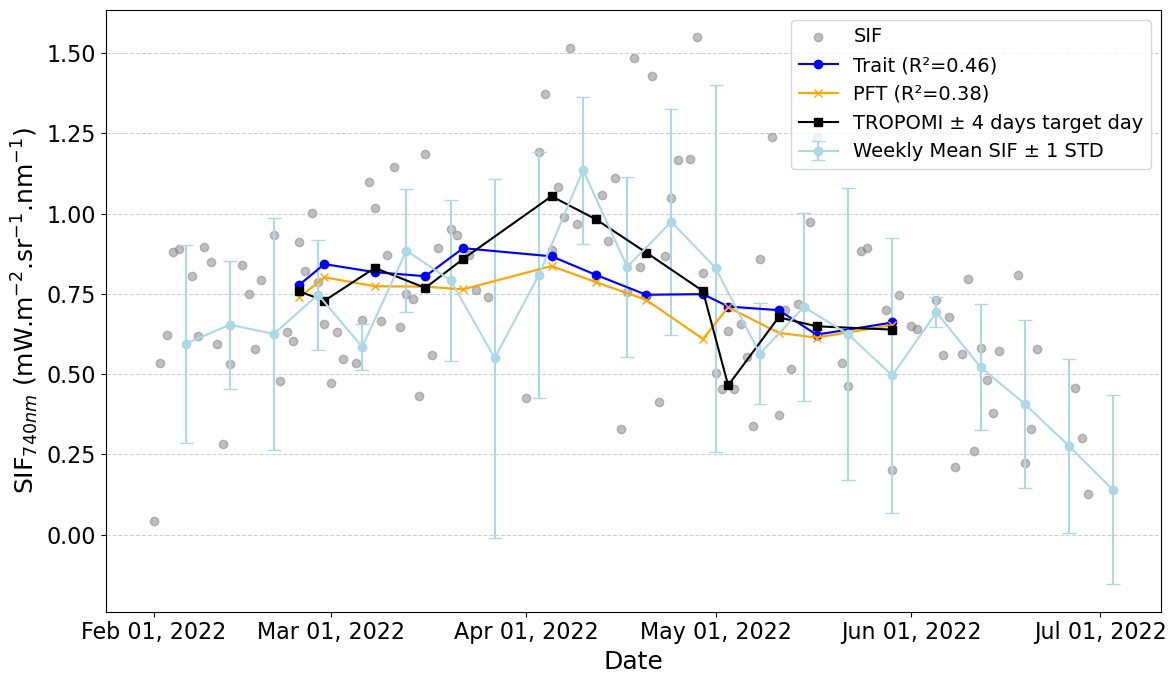

In [257]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress

# Function to calculate 95% confidence interval area
def calc_ci95_area(data):
    mean = np.nanmean(data, axis=(1, 2))
    std = np.nanstd(data, axis=(1, 2))
    count = np.sum(~np.isnan(data), axis=(1, 2))
    ci95_hi = mean + 1.96 * std / np.sqrt(count)
    ci95_lo = mean - 1.96 * std / np.sqrt(count)
    return ci95_lo, ci95_hi

# Load the modified NetCDF file
file_path = "/home/renatob/data/FluoData1/aviris_dangermond/TROPOMI_dangermond/TROPOMI_SIF740nm-v1.005deg_regrid_Dangermond_tll_clipped.nc"
ds = xr.open_dataset(file_path)

# Handle missing values
ds['sif'] = ds['sif'].where(ds['sif'] != -999)

# Convert time to datetime objects using cftime for better handling of non-standard calendars and large values
ds['time'] = xr.cftime_range(start='2022-02-01', periods=len(ds['time']), freq='D', calendar='proleptic_gregorian')
ds['time'] = ds.indexes['time'].to_datetimeindex()

# Compute the mean SIF over all lat/lon for each time step
mean_sif = ds['sif'].mean(dim=['lat', 'lon'], skipna=True)

# Resample to weekly values and compute the mean and standard deviation
weekly_mean_sif = mean_sif.resample(time='W').mean()
weekly_std_sif = mean_sif.resample(time='W').std()

# Given target dates
dates = ["2022-02-24T00:00:00.000000", "2022-02-28T00:00:00.000000", "2022-03-08T00:00:00.000000",
         "2022-03-16T00:00:00.000000", "2022-03-22T00:00:00.000000", "2022-04-05T00:00:00.000000",
         "2022-04-12T00:00:00.000000", "2022-04-20T00:00:00.000000", "2022-04-29T00:00:00.000000",
         "2022-05-03T00:00:00.000000", "2022-05-11T00:00:00.000000", "2022-05-17T00:00:00.000000",
         "2022-05-29T00:00:00.000000"]

# Convert target dates to datetime objects
target_dates = pd.to_datetime(dates)

# Calculate average SIF around each target date (3 days before and after)
average_sif_target_dates = []
for target_date in target_dates:
    start_date = target_date - pd.Timedelta(days=4)
    end_date = target_date + pd.Timedelta(days=4)
    mask = (ds['time'] >= start_date) & (ds['time'] <= end_date)
    average_sif_target_dates.append(mean_sif[mask].mean().item())

average_sif_target_dates = np.array(average_sif_target_dates)

# Plotting the first part
fig, ax = plt.subplots(figsize=(12, 7))

# Plot all original data points
positive_mean_sif = mean_sif.where(mean_sif > 0, np.nan)
ax.scatter(np.array(ds['time']), positive_mean_sif, marker='o', linestyle='-', color='gray', alpha=0.5, label='SIF')

# Plot weekly average with standard deviation as error bars
positive_weekly_mean_sif = weekly_mean_sif.where(weekly_mean_sif > 0, np.nan)
ax.errorbar(np.array(positive_weekly_mean_sif['time']), positive_weekly_mean_sif, yerr=weekly_std_sif, fmt='o', color='lightblue', linestyle='-', capsize=5, label='Weekly Mean SIF ± 1 STD')

# Base file paths
base_file_path_trait = "/home/renatob/data/FluoData1/aviris_dangermond/fitting/fitted_prescribed_lai_ci/shift_fluxes_day_{}_clima_fit_reg_jmax.nc"
base_file_path_pft = "/home/renatob/data/FluoData1/aviris_dangermond/fitting/fitted_prescribed_lai_ci/pft_shift_fluxes_day_{}_clima_fit_reg_jmax.nc"

# Initialize lists to store data
mean_sif740_trait = []
mean_sif740_pft = []
ci95_hi_trait = []
ci95_lo_trait = []
ci95_hi_pft = []
ci95_lo_pft = []

# Convert string dates to pandas datetime objects
date_objects = pd.to_datetime(dates)

for i, date in enumerate(date_objects):
    file_trait = base_file_path_trait.format(str(i).zfill(2))
    file_pft = base_file_path_pft.format(str(i).zfill(2))

    # Open datasets
    ds_trait = xr.open_dataset(file_trait, decode_times=False)
    ds_pft = xr.open_dataset(file_pft, decode_times=False)

    # Calculate mean SIF740 and confidence interval area for Trait and PFT
    mean_sif740_trait.append(ds_trait['sif740'].mean(dim=['lat', 'lon']).values.item())
    mean_sif740_pft.append(ds_pft['sif740'].mean(dim=['lat', 'lon']).values.item())

    ci_lo_trait, ci_hi_trait = calc_ci95_area(ds_trait['sif740'].values)
    ci_lo_pft, ci_hi_pft = calc_ci95_area(ds_pft['sif740'].values)

    ci95_lo_trait.append(ci_lo_trait)
    ci95_hi_trait.append(ci_hi_trait)
    ci95_lo_pft.append(ci_lo_pft)
    ci95_hi_pft.append(ci_hi_pft)

# TROPOMI data two weeks 001
tropomi_sif = average_sif_target_dates.tolist()

# Calculate R^2 values
trait_r2 = linregress(mean_sif740_trait, tropomi_sif).rvalue ** 2
pft_r2 = linregress(mean_sif740_pft, tropomi_sif).rvalue ** 2

# Plotting the second part on the same figure
ax.plot(date_objects, mean_sif740_trait, label=f'Trait (R²={trait_r2:.2f})', marker='o', color='blue')
ax.plot(date_objects, mean_sif740_pft, label=f'PFT (R²={pft_r2:.2f})', marker='x', color='orange')
ax.plot(date_objects, tropomi_sif, label='TROPOMI ± 4 days target day', marker='s', color='black')

# Ensure that the ci95_lo and ci95_hi arrays are 1D by flattening them
ci95_lo_trait = np.array(ci95_lo_trait).flatten()
ci95_hi_trait = np.array(ci95_hi_trait).flatten()
ci95_lo_pft = np.array(ci95_lo_pft).flatten()
ci95_hi_pft = np.array(ci95_hi_pft).flatten()

# Add shaded area for ci95
ax.fill_between(date_objects, ci95_lo_trait, ci95_hi_trait, color='blue', alpha=0.1)
ax.fill_between(date_objects, ci95_lo_pft, ci95_hi_pft, color='orange', alpha=0.1)

# Formatting the plot
ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel(r'SIF$_{740nm}$ (mW.m$^{-2}$.sr$^{-1}$.nm$^{-1}$)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Display month intervals on x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d, %Y"))  # Format x-axis date labels
ax.legend(loc='best', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Save the plot with high DPI for publication
plt.tight_layout()
#plt.savefig('/net/fluo/data3/data/FluoData1/students/renato/aviris_dangermond/traits/figures/clima_fit_prescribed_lai_ci/mean_sif740_combined_over_time_clima_fit_pub_tropomi.png', dpi=300)
plt.show()
